# Projeto Airbnb Rio - Ferramenta de Previsão de Preço de Imóvel para pessoas comuns 

### Objetivo

Construir um modelo de previsão de preço que permita uma pessoa comum que possui um imóvel possa saber quanto deve cobrar pela diária do seu imóvel.

Ou ainda, para o locador comum, dado o imóvel que ele está buscando, ajudar a saber se aquele imóvel está com preço atrativo (abaixo da média para imóveis com as mesmas características) ou não.

### O que temos disponível, inspirações e créditos

As bases de dados foram retiradas do site kaggle: https://www.kaggle.com/allanbruno/airbnb-rio-de-janeiro

### Expectativas Iniciais

- Acredito que a sazonalidade pode ser um fator importante, visto que meses como dezembro costumam ser bem caros no RJ
- A localização do imóvel deve fazer muita diferença no preço, já que no Rio de Janeiro a localização pode mudar completamente as características do lugar (segurança, beleza natural, pontos turísticos)
- Adicionais/Comodidades podem ter um impacto significativo, visto que temos muitos prédios e casas antigos no Rio de Janeiro.

### Importar Bibliotecas

In [1]:
import pandas as pd
import pathlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

### Consolidar Base de Dados

In [2]:
meses = {'jan': 1, 'fev':2, 'mar':3, 'abr': 4, 'mai':5, 'jun': 6, 'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12}
caminho_base = pathlib.Path('dataset')

lista_final = [] # Use um nome diferente para evitar conflitos

# Verifique se a pasta existe
if not caminho_base.exists():
    print("Erro: A pasta 'dataset' não foi encontrada!")
else:
    for arquivo in caminho_base.iterdir():
        if arquivo.suffix == '.csv':
            print(f"Processando: {arquivo.name}") # Confirma que o arquivo foi lido
            
            # Extração
            nome_mes = arquivo.name[:3]
            mes = meses.get(nome_mes) # .get evita erro se o nome for diferente
            
            ano = arquivo.name[-8:]
            ano = int(ano.replace(".csv", ""))

            # Leitura
            df_temp = pd.read_csv(arquivo)
            
            # CRIAÇÃO DAS COLUNAS
            df_temp['ano'] = ano
            df_temp['mes'] = mes
            
            # Verificação imediata
            if 'ano' in df_temp.columns:
                print(f"   -> Colunas mes/ano criadas no DF temporário.")
            
            lista_final.append(df_temp)

    # Concatenação final
    if lista_final:
        base = pd.concat(lista_final, ignore_index=True)
        print("\n--- SUCESSO ---")
        print(f"Colunas finais no DF 'base': {base.columns.tolist()}")
        print(base[['mes', 'ano']].head()) # Mostra as primeiras linhas das colunas novas
    else:
        print("\n--- ERRO ---")
        print("Nenhum arquivo CSV foi processado. Verifique os nomes dos arquivos.")

Processando: abril2018.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\224946130.py:22: DtypeWarning: Columns (0: monthly_price, 1: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.
Processando: abril2019.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\224946130.py:22: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.
Processando: abril2020.csv


...

   -> Colunas mes/ano criadas no DF temporário.
Processando: setembro2018.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\224946130.py:22: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.
Processando: setembro2019.csv


C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\224946130.py:22: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(arquivo)


   -> Colunas mes/ano criadas no DF temporário.

--- SUCESSO ---
Colunas finais no DF 'base': ['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms

### Remover todas as colunas que contenham links (url)

In [3]:
# Identifica colunas que contêm 'url'
remover = [coluna for coluna in base.columns if 'url' in coluna.lower()]

# Deleta as colunas encontradas
base.drop(columns=remover, inplace=True)

print(f"Colunas removidas: {remover}")

Colunas removidas: ['listing_url', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url']


### Remover todas as colunas que contenham ID

In [4]:
remover = [coluna for coluna in base.columns if 'id' in coluna.lower()]

# Deleta as colunas encontradas
base.drop(columns=remover, inplace=True)

print(f"Colunas removidas: {remover}")

base.info(verbose=True, show_counts=True)

Colunas removidas: ['id', 'scrape_id', 'host_id', 'host_identity_verified']
<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 96 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   last_scraped                                  902210 non-null  str    
 1   name                                          900538 non-null  str    
 2   summary                                       860406 non-null  str    
 3   space                                         543496 non-null  str    
 4   description                                   884040 non-null  str    
 5   experiences_offered                           902210 non-null  str    
 6   neighborhood_overview                         481672 non-null  str    
 7   notes                                         284885 non-null  str    
 8   transit                                       476428 non-nu

### Remover colunas com muitas NAN

In [5]:
# Verifica a porcentagem de nulos por coluna
nulos = base.isnull().mean() * 100
colunas_muitos_nulos = nulos[nulos > 50].index.tolist()


# 2. Exclui do DataFrame
base = base.drop(columns=colunas_muitos_nulos)

# 3. Verifica o novo tamanho do DataFrame
print(f"Foram removidas {(colunas_muitos_nulos)} colunas.")
print(f"Novo formato do DataFrame: {base.shape}")

Foram removidas ['notes', 'access', 'interaction', 'host_about', 'host_acceptance_rate', 'neighbourhood_group_cleansed', 'square_feet', 'weekly_price', 'monthly_price', 'license', 'jurisdiction_names'] colunas.
Novo formato do DataFrame: (902210, 85)


### Remover colunas com valor único (todos iguais)

In [6]:
# Identifica colunas que têm apenas 1 valor único
colunas_inuteis = [col for col in base.columns if base[col].nunique() <= 1]

# 2. Exclui do DataFrame
base = base.drop(columns=colunas_inuteis)

# 3. Verifica o novo tamanho do DataFrame
print(f"Foram removidas {(colunas_inuteis)} colunas.")
print(f"Novo formato do DataFrame: {base.shape}")

Foram removidas ['experiences_offered', 'has_availability', 'requires_license', 'is_business_travel_ready'] colunas.
Novo formato do DataFrame: (902210, 81)


In [7]:
base.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 81 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   last_scraped                                  902210 non-null  str    
 1   name                                          900538 non-null  str    
 2   summary                                       860406 non-null  str    
 3   space                                         543496 non-null  str    
 4   description                                   884040 non-null  str    
 5   neighborhood_overview                         481672 non-null  str    
 6   transit                                       476428 non-null  str    
 7   house_rules                                   457813 non-null  str    
 8   host_name                                     901750 non-null  str    
 9   host_since                                    901750 non-nu

### Ver colunas no excel

In [8]:
# base.head(500).to_csv('verificar_colunas.csv', sep=';')

### Remover uma lista de colunas selecionadas manualmente

In [9]:
colunas_para_remover = ['calendar_last_scraped','require_guest_phone_verification','last_scraped', 'name', 'summary','host_name', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_total_listings_count', 'host_verifications','city', 'state', 'zipcode', 'country', 'description','host_has_profile_pic', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'market', 'smart_location', 'country_code', 'is_location_exact', 'require_guest_profile_picture', 'require_guest_profile_picture', 'calendar_updated', 'availability_30', 'availability_60', 'availability_90', 'availability_365']
base = base.drop(columns=colunas_para_remover)

# 3. Verifica o novo tamanho do DataFrame
print(f"Foram removidas {(colunas_para_remover)} colunas.")
print(f"Novo formato do DataFrame: {base.shape}")

Foram removidas ['calendar_last_scraped', 'require_guest_phone_verification', 'last_scraped', 'name', 'summary', 'host_name', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_total_listings_count', 'host_verifications', 'city', 'state', 'zipcode', 'country', 'description', 'host_has_profile_pic', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'market', 'smart_location', 'country_code', 'is_location_exact', 'require_guest_profile_picture', 'require_guest_profile_picture', 'calendar_updated', 'availability_30', 'availability_60', 'availability_90', 'availability_365'] colunas.
Novo formato do DataFrame: (902210, 50)


### Tratar Valores Faltando

In [10]:
print(base.isna().sum())   # mostre o somatório de linhas com valores vazios para cada coluna

space                                           358714
neighborhood_overview                           420538
transit                                         425782
house_rules                                     444397
host_is_superhost                                  460
host_neighbourhood                              346612
host_listings_count                                460
latitude                                             0
longitude                                            0
property_type                                        0
room_type                                            0
accommodates                                         0
bathrooms                                         1724
bedrooms                                           850
beds                                              2502
bed_type                                             0
amenities                                            0
price                                                0
security_d

In [11]:
# Exclui colunas com mais de 50% (300 mil) valores nulos

for coluna in base:
    if base[coluna].isna().sum() > 300000:
        base = base.drop(coluna, axis = 1)

# 3. Verifica o novo tamanho do DataFrame
print(f"Novo formato do DataFrame: {base.shape}")

Novo formato do DataFrame: (902210, 23)


### Excluir linhas com valores vazios em pelo menos 3 colunas

In [12]:
# cria uma nova coluna com a contagem de NaNs por linha
base['total_nan_na_linha'] = base.isna().sum(axis=1)

# Pega os índices das linhas que têm mais de 2 NaNs
indices_para_excluir = base[base['total_nan_na_linha'] > 3].index

# Exclui essas linhas pelo índice
base = base.drop(indices_para_excluir)

# Exclui a coluna criada no inicio  para contagem de nanas por linha
base = base.drop(columns = ['total_nan_na_linha'])

print(f"Novo formato do DataFrame: {base.shape}")

Novo formato do DataFrame: (902208, 23)


In [13]:
# Excluir linhas que tenham valor nan

base = base.dropna()
print(f"Novo formato do DataFrame: {base.shape}")

Novo formato do DataFrame: (897709, 23)


### Verificar Tipos de Dados em cada coluna

In [14]:
print(base.dtypes)



host_is_superhost                     str
host_listings_count               float64
latitude                          float64
longitude                         float64
property_type                         str
room_type                             str
accommodates                        int64
bathrooms                         float64
bedrooms                          float64
beds                              float64
bed_type                              str
amenities                             str
price                                 str
guests_included                     int64
extra_people                          str
minimum_nights                      int64
maximum_nights                      int64
number_of_reviews                   int64
instant_bookable                      str
cancellation_policy                   str
calculated_host_listings_count      int64
ano                                 int64
mes                                 int64
dtype: object


In [15]:
print(base.iloc[0])

host_is_superhost                                                                 f
host_listings_count                                                             1.0
latitude                                                                 -22.946854
longitude                                                                -43.182737
property_type                                                             Apartment
room_type                                                           Entire home/apt
accommodates                                                                      4
bathrooms                                                                       1.0
bedrooms                                                                        0.0
beds                                                                            2.0
bed_type                                                                   Real Bed
amenities                         {TV,Internet,"Air conditioning",Kitchen,Do

### Transformando valores de string para float

In [16]:
base['price'] = base['price'].str.replace('$',"")
base['price'] = base['price'].str.replace(',',"")
base['price'] = base['price'].astype(np.float32, copy=False)

base['extra_people'] = base['extra_people'].str.replace('$',"")
base['extra_people'] = base['extra_people'].str.replace(',',"")
base['extra_people'] = base['extra_people'].astype(np.float32, copy=False)

C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\2137548055.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base['price'] = base['price'].astype(np.float32, copy=False)
C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\2137548055.py:7: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  base['extra_people'] = base['extra_people'].astype(np.float32, copy=False)


### Análise Exploratória e Tratar Outliers

### Outliers
#### amplitude = Q3 - Q1
#### limite inferior = Q1 - 1,5 * amplitude  (abixo disso, é outlier)
#### limite superior = Q3 + 1,5 * amplitude (acima disso é outlier)


<Axes: >

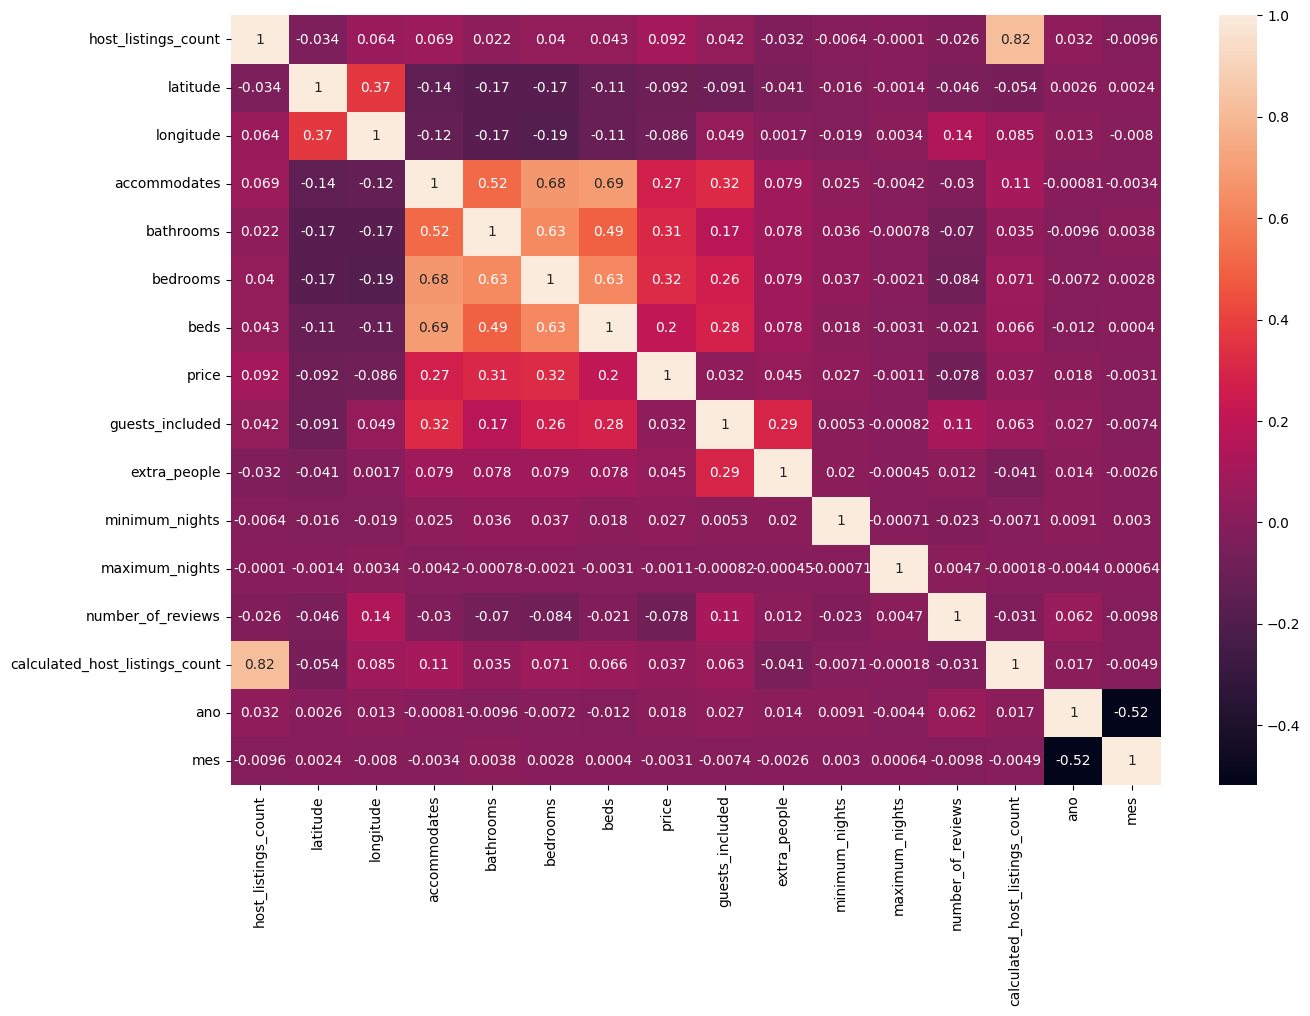

In [17]:
# Correlação
plt.figure(figsize=(15,10))
sns.heatmap(base.corr(numeric_only=True), annot=True)


In [18]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1
    return q1 - 1.5*amplitude , q3 + 1.5 * amplitude


def excluir_outliers(df, nome_coluna):
    qtde_linhas = df.shape[0]  #.shape mostra uma tupla com nº linhas e nº colunas. O indice zero pega as linhas
    lim_inf, lim_sup = limites(df[nome_coluna])
    df = df.loc[(df[nome_coluna] >=lim_inf) & (df[nome_coluna] <=lim_sup) ,:]
    linhas_removidas = qtde_linhas - df.shape[0]
    return df , linhas_removidas



In [19]:
def diagrama_caixa(coluna):
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_size_inches(15,5)
    sns.boxplot(x=coluna, ax=ax1)
    ax2.set_xlim(limites(coluna))
    sns.boxplot(x=coluna, ax=ax2)


def histograma(coluna):
    plt.figure(figsize =(15, 5))
    sns.histplot(coluna, kde=True)

def grafico_barras(coluna):
    plt.figure(figsize=(15,5))
    ax = sns.barplot(x=coluna.value_counts().index, y=coluna.value_counts())
    ax.set_xlim(limites(coluna))
    

### Exlusão outliers da coluna PRICE (quantidade valores contínuos)

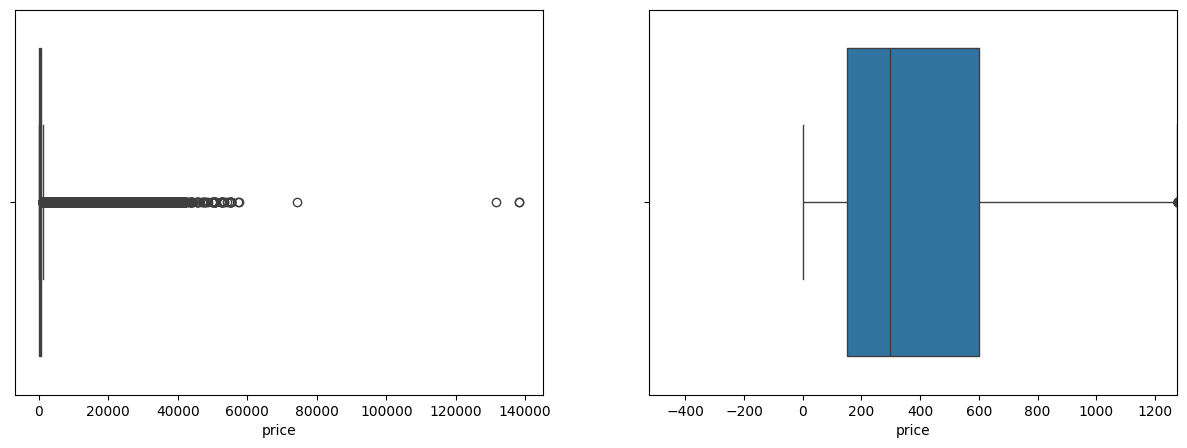

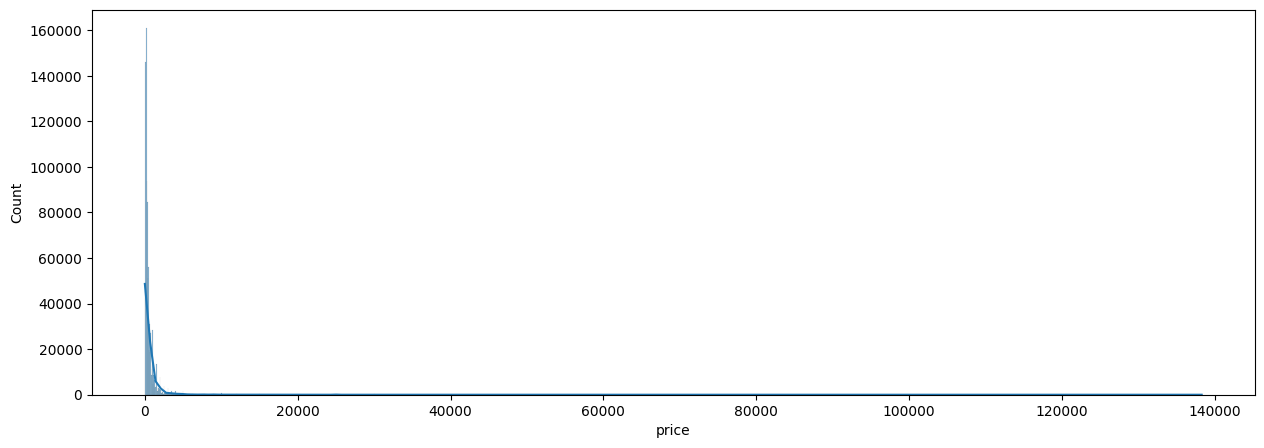

In [20]:
diagrama_caixa(base['price'])
histograma(base['price'])

In [21]:
base, linhas_removidas = excluir_outliers(base,'price')

print(f'Foram excluídas {linhas_removidas} linhas')
print(f'Restaram {base.shape[0]} linhas')

Foram excluídas 87282 linhas
Restaram 810427 linhas


### Exlusão outliers da coluna EXTRA_PEOPLE (quantidade valores contínuos)

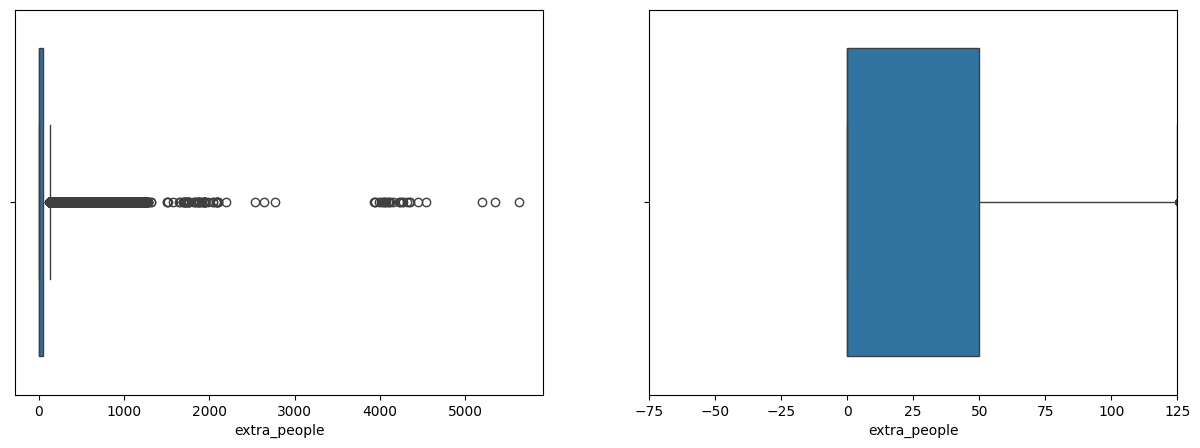

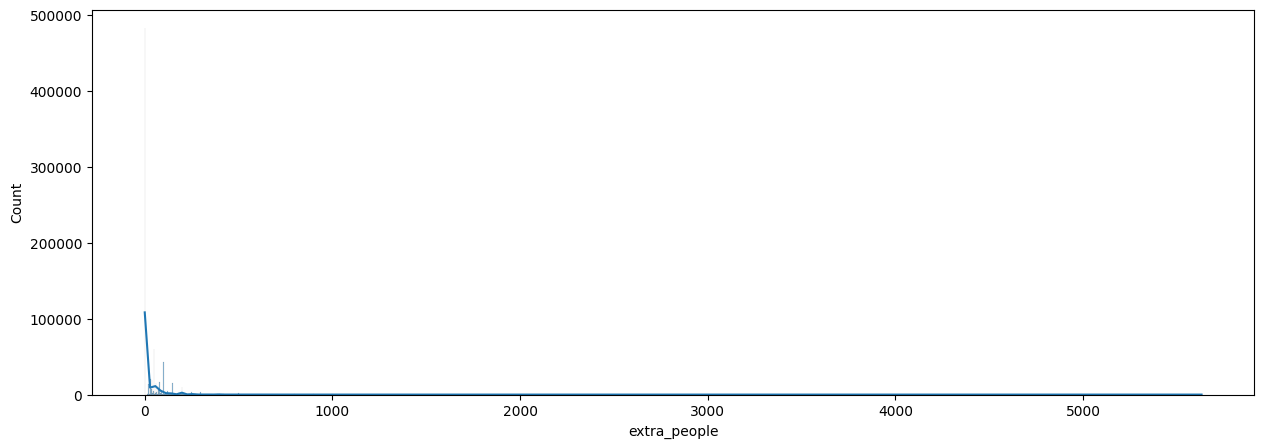

In [22]:
diagrama_caixa(base['extra_people'])
histograma(base['extra_people'])

In [23]:
base, linhas_removidas = excluir_outliers(base,'extra_people')

print(f'Foram excluídas {linhas_removidas} linhas')
print(f'Restaram {base.shape[0]} linhas')

Foram excluídas 59194 linhas
Restaram 751233 linhas


## Analise de valores discretos


### host_listings_count (qtos imóveis o host tem no airbnb)

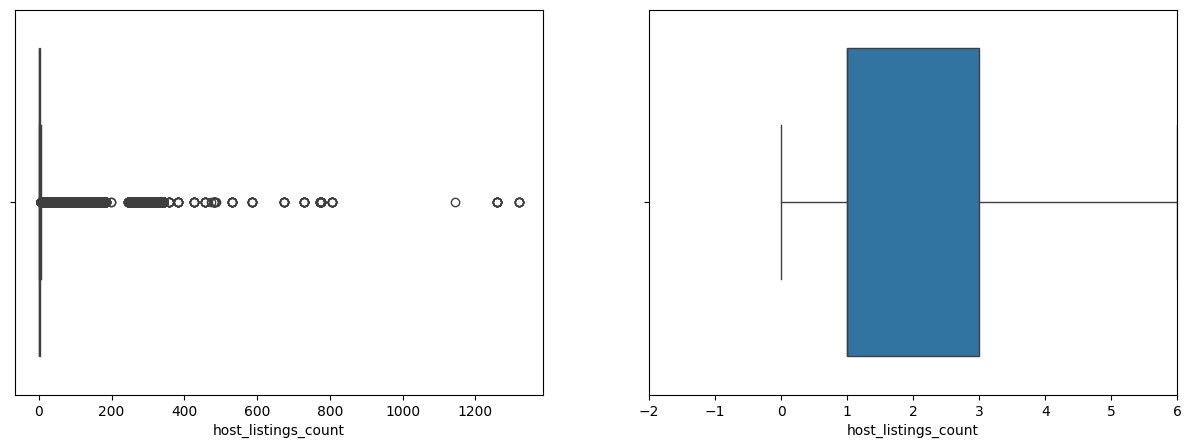

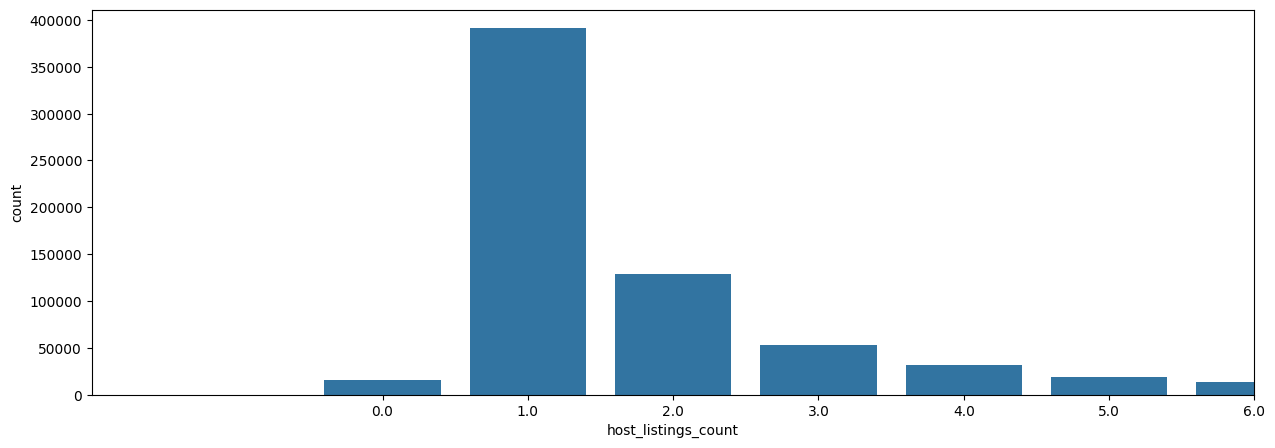

In [24]:
diagrama_caixa(base['host_listings_count'])
grafico_barras(base['host_listings_count'])

##### Podemos excluir os outleirs pq os hosts com masi de 6 imóveis no airbnb não é o público alvo do objetivo do projeto.

In [25]:
base, linhas_removidas = excluir_outliers(base,'host_listings_count')

print(f'Foram excluídas {linhas_removidas} linhas')
print(f'Restaram {base.shape[0]} linhas')

Foram excluídas 97723 linhas
Restaram 653510 linhas


### accommodates (qtas pessoas cabem no imóvel)

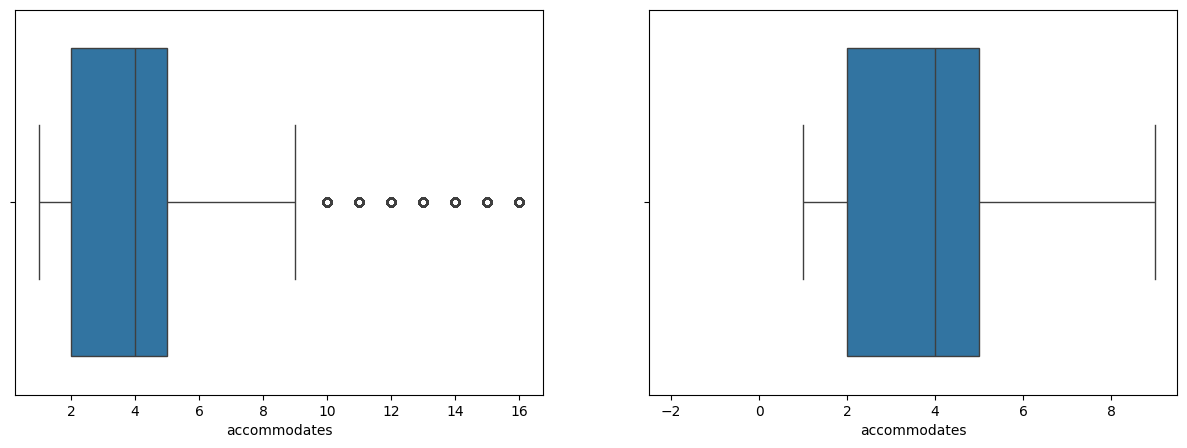

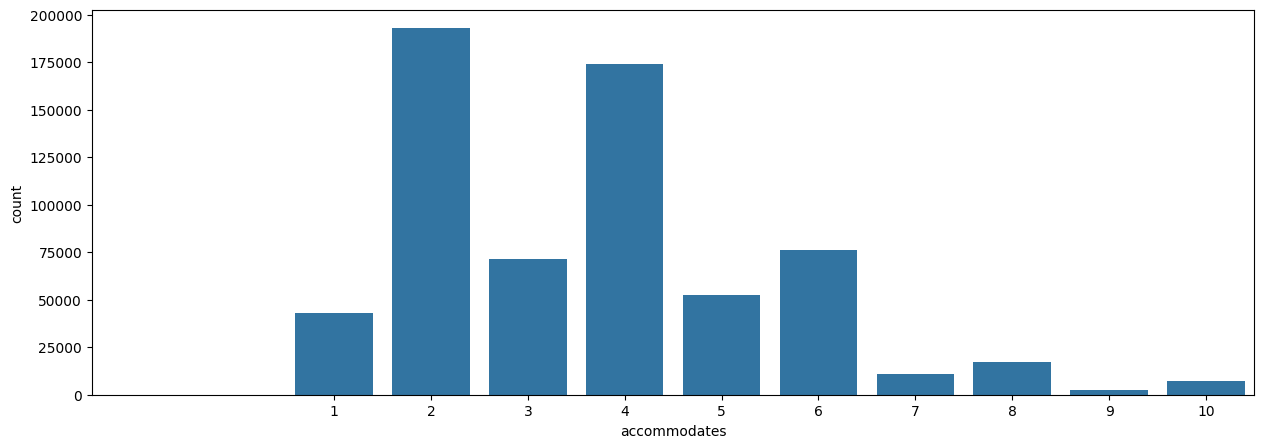

In [26]:
diagrama_caixa(base['accommodates'])
grafico_barras(base['accommodates'])

In [27]:
base, linhas_removidas = excluir_outliers(base,'accommodates')

print(f'Foram excluídas {linhas_removidas} linhas')
print(f'Restaram {base.shape[0]} linhas')

Foram excluídas 13146 linhas
Restaram 640364 linhas


### bathrooms

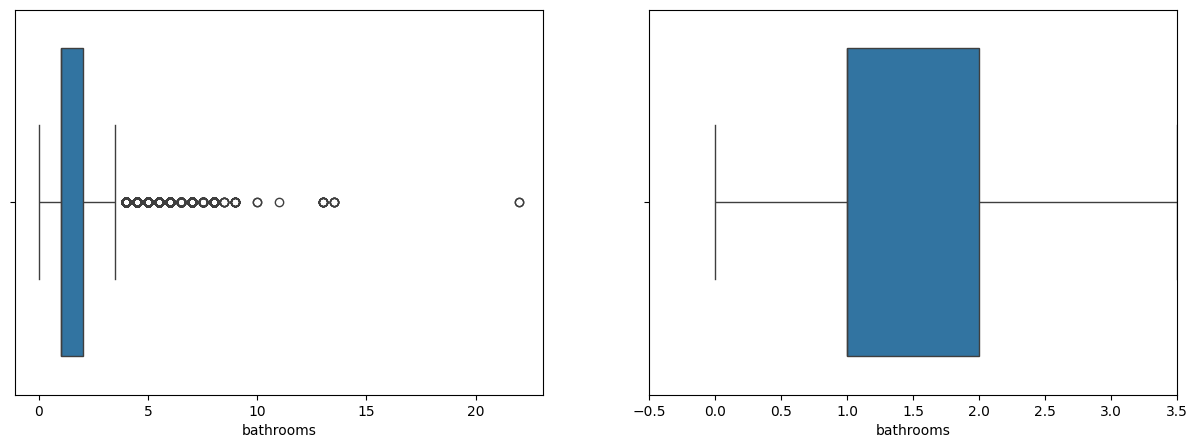

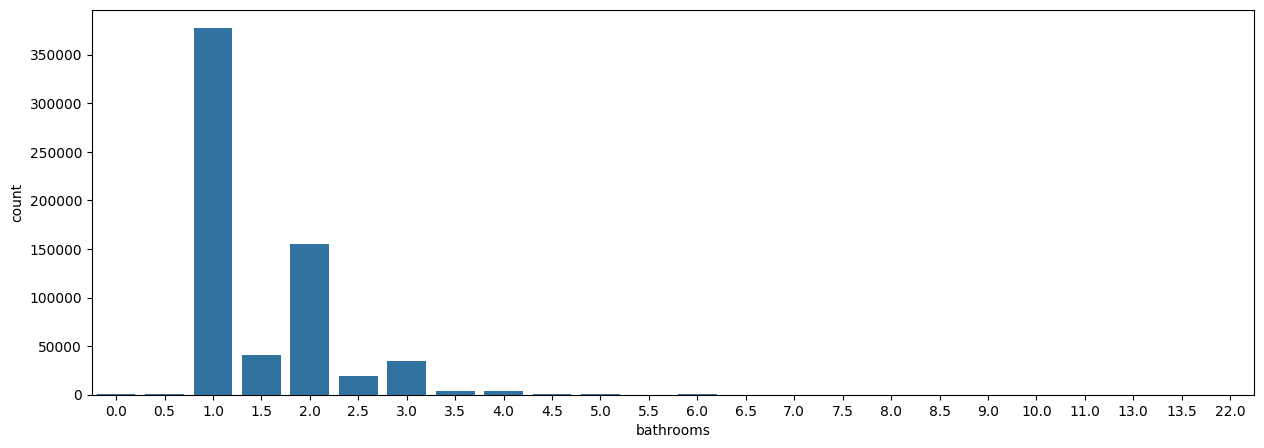

In [28]:
diagrama_caixa(base['bathrooms'])
plt.figure(figsize=(15,5))
ax = sns.barplot(x=base['bathrooms'].value_counts().index, y=base['bathrooms'].value_counts())

In [29]:
base, linhas_removidas = excluir_outliers(base,'bathrooms')

print(f'Foram excluídas {linhas_removidas} linhas')
print(f'Restaram {base.shape[0]} linhas')

Foram excluídas 6894 linhas
Restaram 633470 linhas


### bedrooms

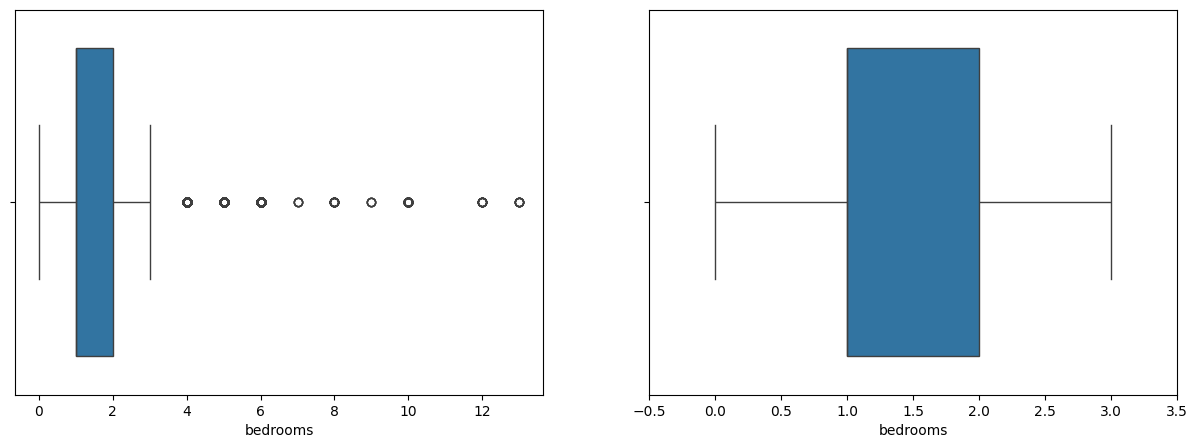

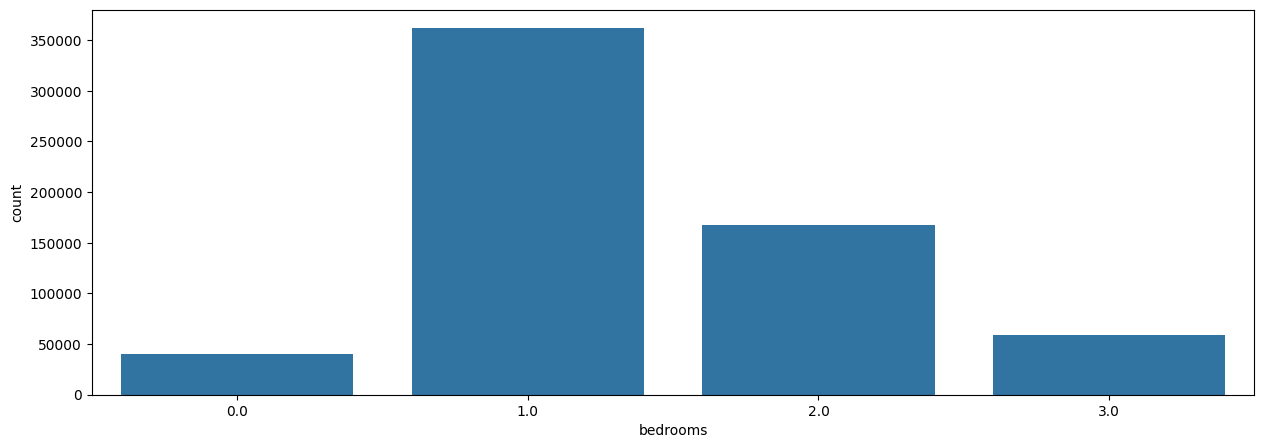

In [30]:
diagrama_caixa(base['bedrooms'])
grafico_barras(base['bedrooms'])

In [31]:
base, linhas_removidas = excluir_outliers(base,'bedrooms')

print(f'Foram excluídas {linhas_removidas} linhas')
print(f'Restaram {base.shape[0]} linhas')

Foram excluídas 5482 linhas
Restaram 627988 linhas


### beds

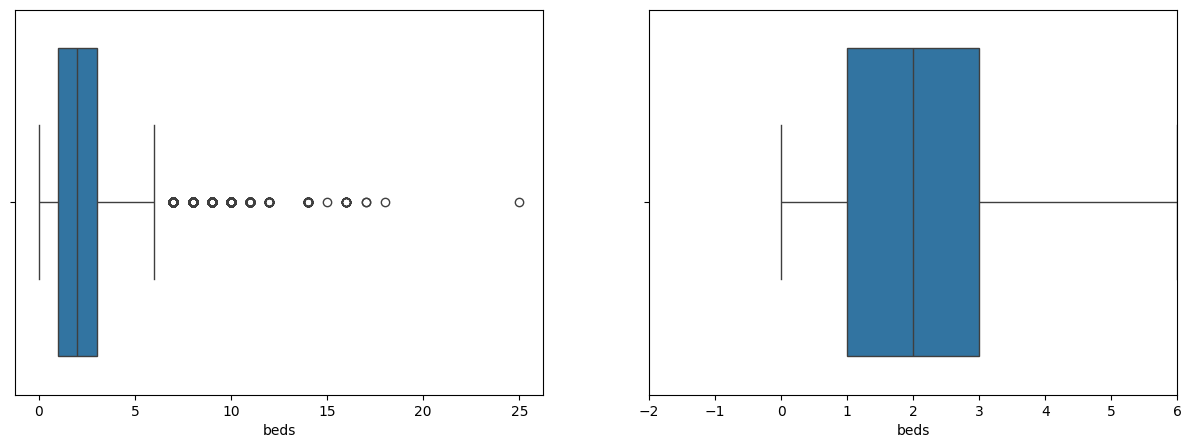

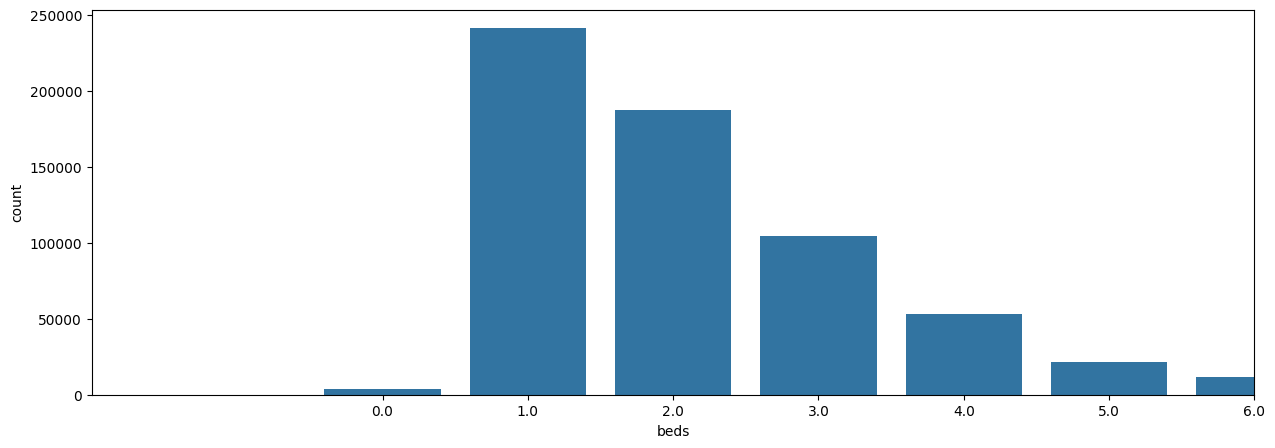

In [32]:
diagrama_caixa(base['beds'])
grafico_barras(base['beds'])

In [33]:
base, linhas_removidas = excluir_outliers(base,'beds')

print(f'Foram excluídas {linhas_removidas} linhas')
print(f'Restaram {base.shape[0]} linhas')

Foram excluídas 5622 linhas
Restaram 622366 linhas


### guests_included

C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\1278064439.py:5: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(limites(coluna))
C:\Users\Andre\AppData\Local\Temp\ipykernel_6260\1278064439.py:16: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(limites(coluna))


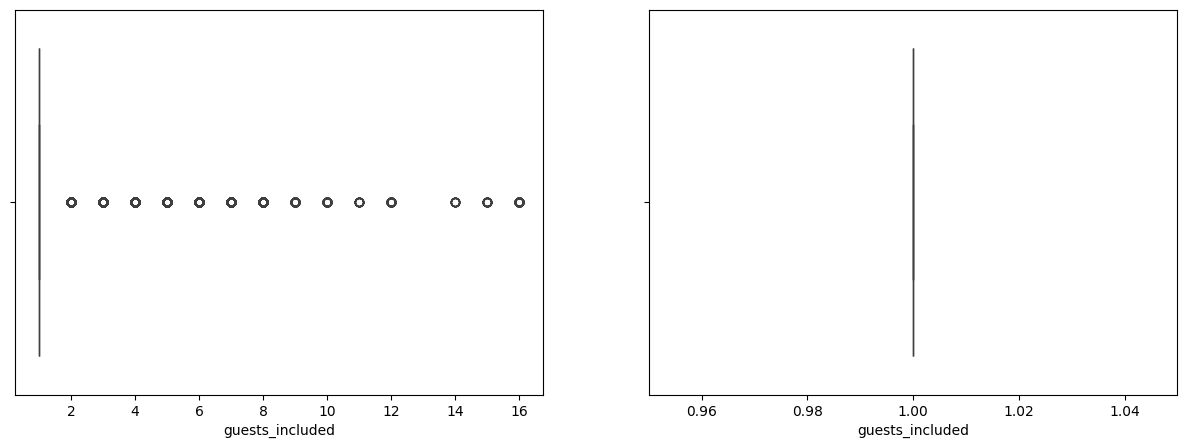

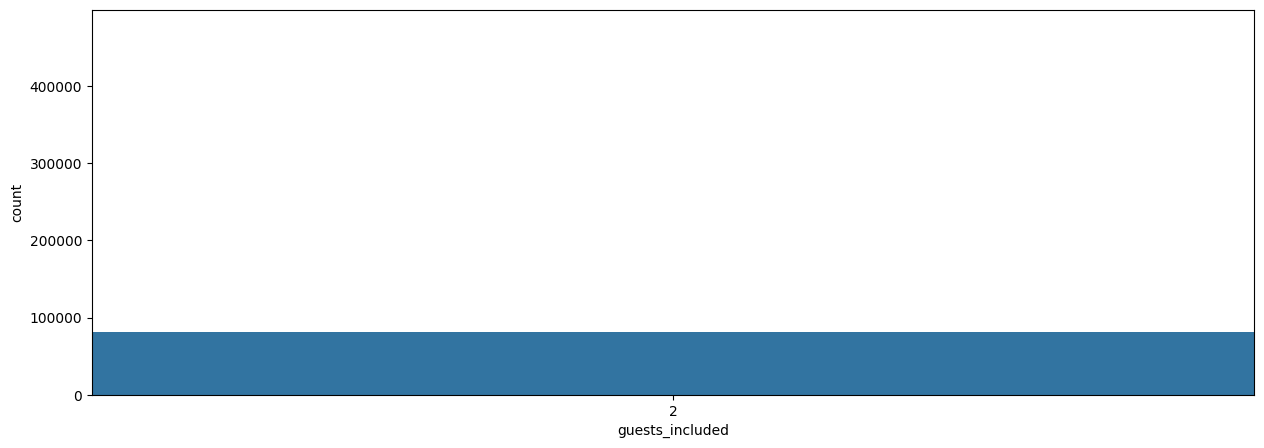

In [34]:
diagrama_caixa(base['guests_included'])
grafico_barras(base['guests_included'])

In [35]:
# Excluir a coluna pois os valores estão distorcidos, possivelmente por falha no cadastramento

base = base.drop('guests_included', axis=1)
print(f'Restaram {base.shape[1]} Colunas')

Restaram 22 Colunas


### minimum_nights

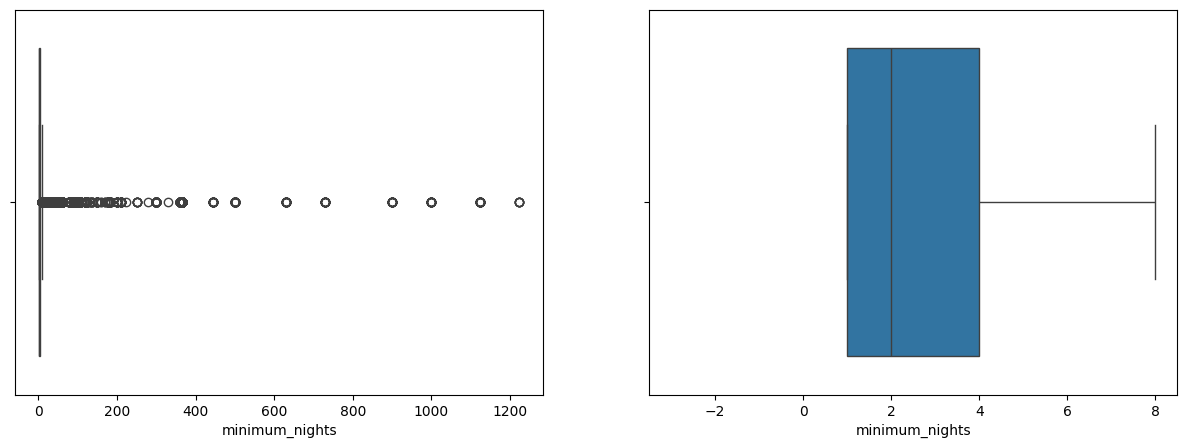

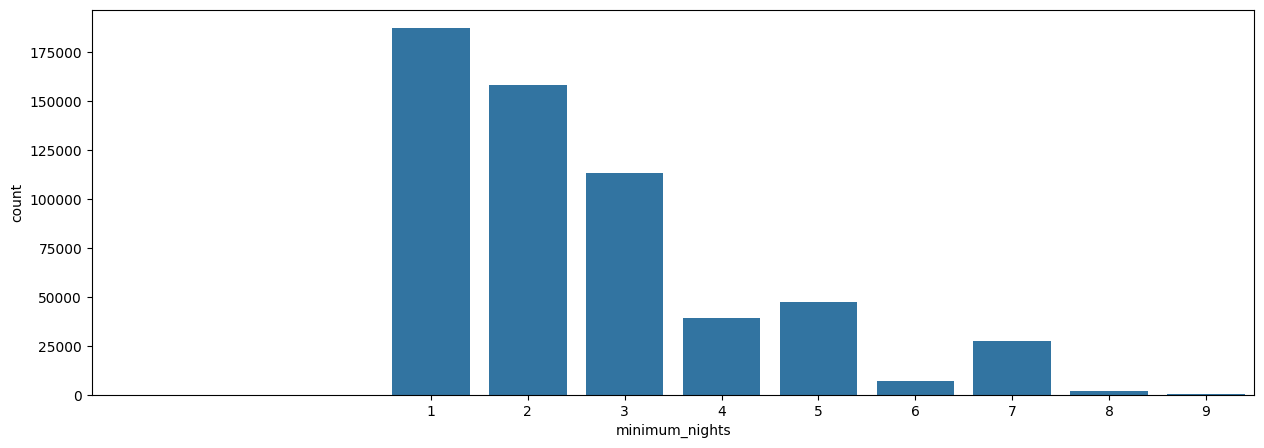

In [36]:
diagrama_caixa(base['minimum_nights'])
grafico_barras(base['minimum_nights'])

In [37]:
# Não serão removidos

#base, linhas_removidas = excluir_outliers(base,'minimum_nights')

#print(f'Foram excluídas {linhas_removidas} linhas')
#print(f'Restaram {base.shape[0]} linhas')

### maximum_nights

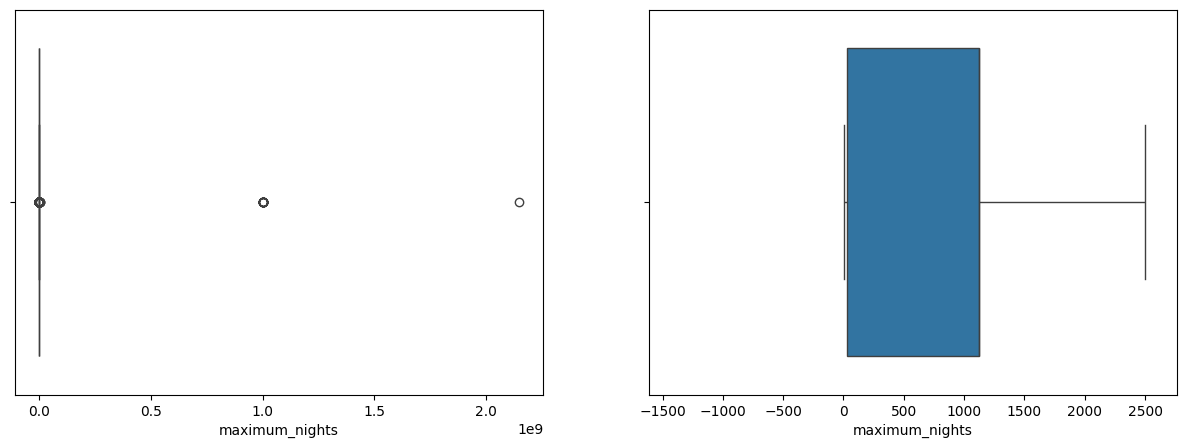

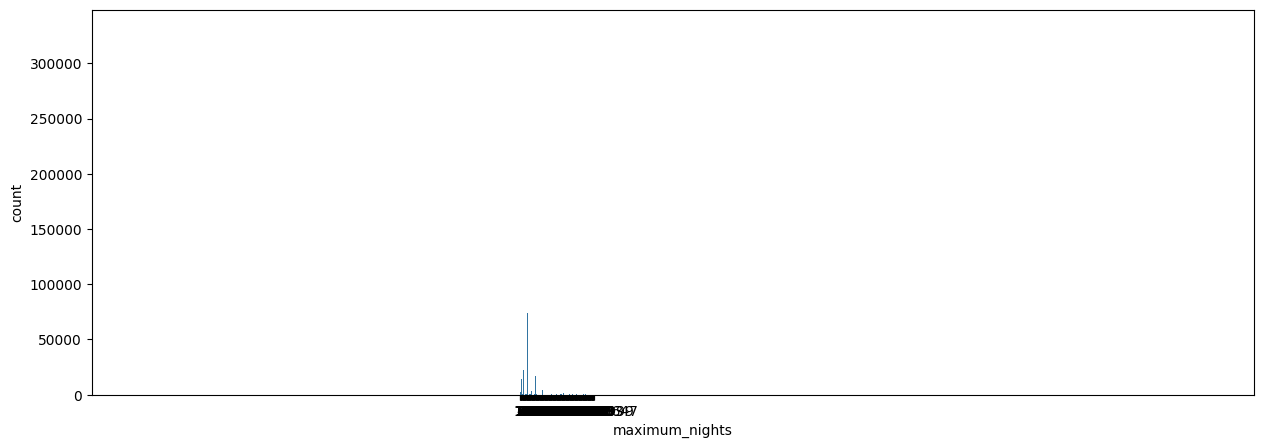

In [38]:
diagrama_caixa(base['maximum_nights'])
grafico_barras(base['maximum_nights'])

# como não influencia na analise, será mantido

### number_of_reviews

A coluna será excluída pois muitos rewies significa imovel bem avaliado e com muito tempo de locação

In [39]:
base = base.drop('number_of_reviews', axis=1)
print(f'Restaram {base.shape[1]} Colunas')

Restaram 21 Colunas


### Tratamento de colunas de Valores de Texto

#### property_type

property_type
Apartment                 492790
House                      54273
Condominium                27679
Serviced apartment         13151
Loft                       12787
Guest suite                 3748
Bed and breakfast           3522
Hostel                      2839
Guesthouse                  2237
Other                       2070
Villa                       1384
Townhouse                   1032
Aparthotel                   720
Earth house                  545
Tiny house                   489
Chalet                       481
Boutique hotel               449
Hotel                        376
Casa particular (Cuba)       328
Cottage                      247
Bungalow                     213
Dorm                         191
Cabin                        141
Nature lodge                 124
Castle                        80
Treehouse                     76
Boat                          65
Island                        54
Hut                           40
Campsite                     

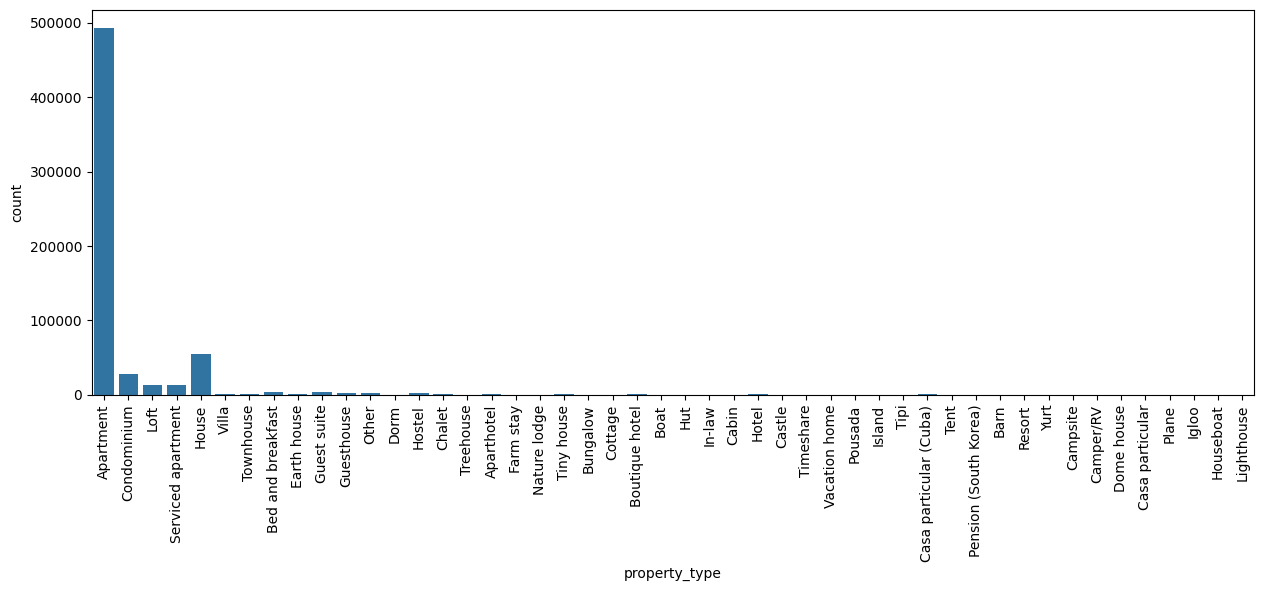

In [40]:
print(base['property_type'].value_counts())

plt.figure(figsize=(15,5))
grafico = sns.countplot(x='property_type', data=base)
grafico.tick_params(axis='x', rotation=90)

In [41]:
contagem = base['property_type'].value_counts()

agrupar = contagem[contagem <= 2100].index.tolist()

print(f"Categorias com poucas ocorrências: {agrupar}")


Categorias com poucas ocorrências: ['Other', 'Villa', 'Townhouse', 'Aparthotel', 'Earth house', 'Tiny house', 'Chalet', 'Boutique hotel', 'Hotel', 'Casa particular (Cuba)', 'Cottage', 'Bungalow', 'Dorm', 'Cabin', 'Nature lodge', 'Castle', 'Treehouse', 'Boat', 'Island', 'Hut', 'Campsite', 'Tent', 'Resort', 'Camper/RV', 'Yurt', 'Tipi', 'Barn', 'Farm stay', 'Pension (South Korea)', 'Dome house', 'In-law', 'Igloo', 'Vacation home', 'Timeshare', 'Pousada', 'Casa particular', 'Houseboat', 'Plane', 'Lighthouse']


In [42]:
base.loc[base['property_type'].isin(agrupar), 'property_type'] = 'Outros'

# Conferindo o resultado
print(base['property_type'].value_counts())

property_type
Apartment             492790
House                  54273
Condominium            27679
Serviced apartment     13151
Loft                   12787
Outros                  9340
Guest suite             3748
Bed and breakfast       3522
Hostel                  2839
Guesthouse              2237
Name: count, dtype: int64


### bed_type

In [43]:
print(base['bed_type'].value_counts())

bed_type
Real Bed         610238
Pull-out Sofa      8475
Futon              1727
Airbed             1349
Couch               577
Name: count, dtype: int64


In [44]:
contagem = base['bed_type'].value_counts()

agrupar = contagem[contagem <= 8500].index.tolist()

base.loc[base['bed_type'].isin(agrupar), 'bed_type'] = 'Others beds'

# Conferindo o resultado
print(base['bed_type'].value_counts())



bed_type
Real Bed       610238
Others beds     12128
Name: count, dtype: int64


### cancellation_policy


In [45]:
print(base['cancellation_policy'].value_counts())

cancellation_policy
flexible                       282175
strict_14_with_grace_period    212280
moderate                       117567
strict                          10177
super_strict_60                   135
super_strict_30                    32
Name: count, dtype: int64


In [46]:
contagem = base['cancellation_policy'].value_counts()

agrupar = contagem[contagem <= 11000].index.tolist()

base.loc[base['cancellation_policy'].isin(agrupar), 'cancellation_policy'] = 'Stricts'

# Conferindo o resultado
print(base['cancellation_policy'].value_counts())

cancellation_policy
flexible                       282175
strict_14_with_grace_period    212280
moderate                       117567
Stricts                         10344
Name: count, dtype: int64


### amenities

In [47]:
print(base['amenities'].value_counts())

amenities
{}                                                                                                                                                                                                                                                                   6539
{TV,"Cable TV",Internet,Wifi,"Air conditioning",Kitchen,Doorman,Elevator,"Buzzer/wireless intercom",Washer}                                                                                                                                                           353
{"translation missing: en.hosting_amenity_49","translation missing: en.hosting_amenity_50"}                                                                                                                                                                           277
{TV,"Cable TV",Internet,Wifi,"Air conditioning",Kitchen,Doorman,Elevator,"Buzzer/wireless intercom","Family/kid friendly",Washer}                                                               

#### Criar uma lista para armazenar todos os itens encontrados

In [48]:

todas_amenidades = []

for linha in base['amenities']:
    # Limpeza básica: remove as chaves {} e as aspas "
    limpo = linha.strip('{}').replace('"', '')
    # Divide pela vírgula e remove espaços extras
    itens = [item.strip() for item in limpo.split(',') if item]
    todas_amenidades.extend(itens)

# 2. Contar a frequência de cada item e transformar em um DataFrame para facilitar a leitura
contagem_amenidades = Counter(todas_amenidades)
df_amenidades = pd.DataFrame.from_dict(contagem_amenidades, orient='index', columns=['quantidade'])
df_amenidades = df_amenidades.sort_values(by='quantidade', ascending=False)

print(df_amenidades.head(30)) # Mostra os 30 itens mais comuns

                           quantidade
Kitchen                        568486
Wifi                           546061
Essentials                     512640
TV                             492049
Air conditioning               473622
Elevator                       451462
Washer                         419486
Hangers                        406902
Iron                           374859
Laptop friendly workspace      347608
Family/kid friendly            309557
Cable TV                       247451
Hair dryer                     232754
Smoking allowed                229106
Hot water                      227444
Free parking on premises       223761
Buzzer/wireless intercom       208945
Doorman                        206830
Lock on bedroom door           196591
Internet                       185692
Shampoo                        177657
Fire extinguisher              158058
Pool                           156411
Dishes and silverware          142576
Refrigerator                   139246
Bed linens  

#### Verifique se existem alguns itens e cria colunas com sim ou não

In [49]:
# Recriando as colunas como booleanas (True ou False)
base['internet_wifi'] = base['amenities'].str.contains('Wifi|Internet', case=False)
base['ar condicionado'] = base['amenities'].str.contains('Air conditioning', case=False)
base['tv'] = base['amenities'].str.contains('TV|Cable TV', case=False)
base['água quente'] = base['amenities'].str.contains('Hot water', case=False)
base['piscina'] = base['amenities'].str.contains('Pool', case=False)

# Tratando valores nulos (se houver amenities vazias, vira False em vez de NaN)
colunas_novas = ['internet_wifi', 'ar condicionado', 'tv', 'água quente', 'piscina']
base[colunas_novas] = base[colunas_novas].fillna(False)

# Verificando os tipos de dados
print(base[colunas_novas].dtypes)

internet_wifi      bool
ar condicionado    bool
tv                 bool
água quente        bool
piscina            bool
dtype: object


In [50]:
base = base.drop(columns = ['amenities'])

## Rever a correlação

<Axes: >

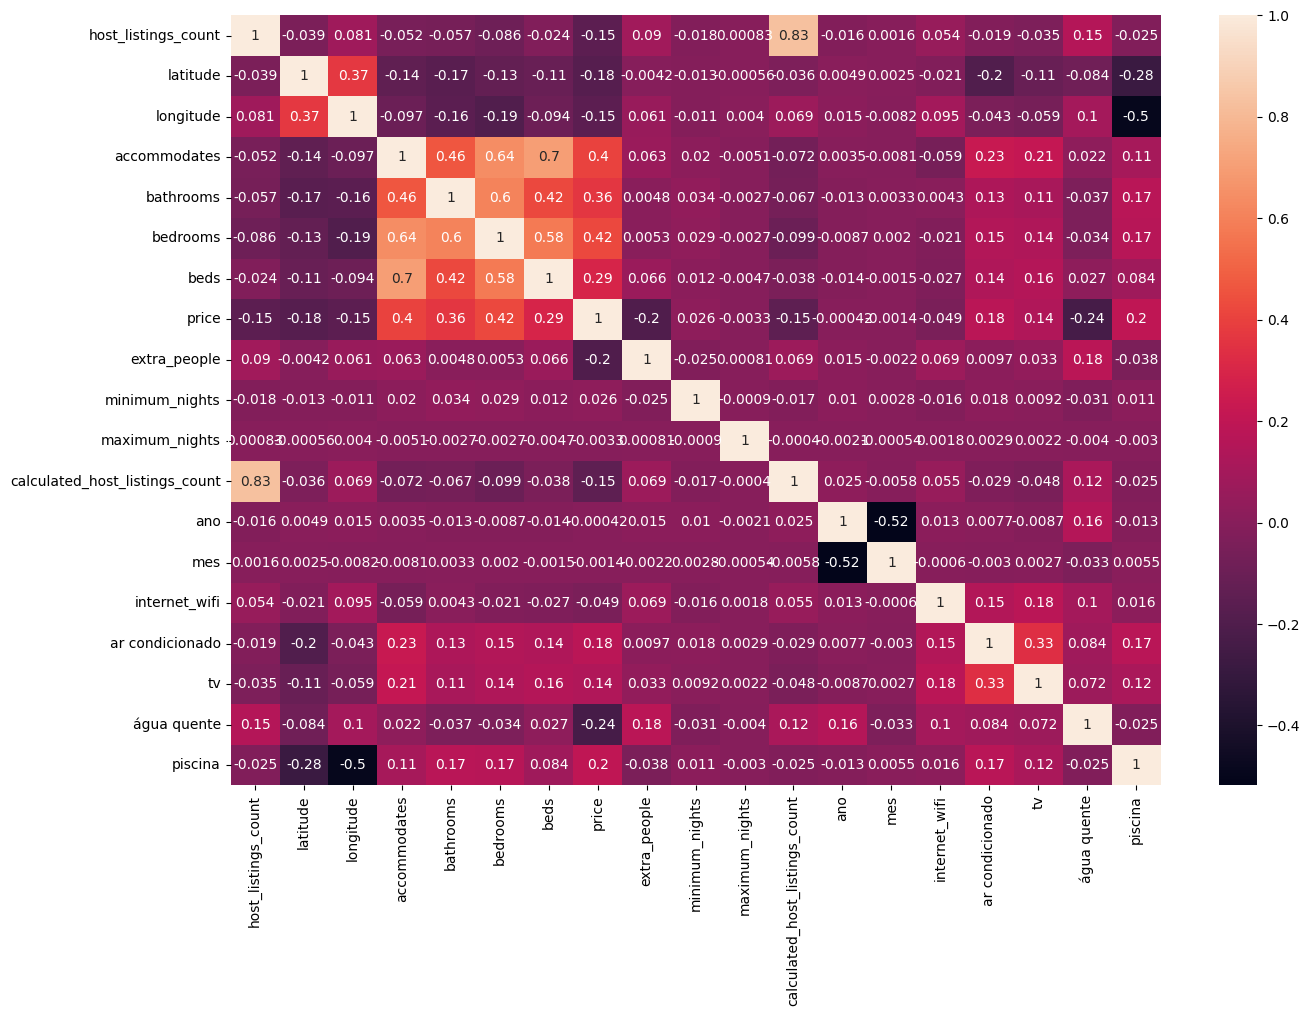

In [51]:
plt.figure(figsize=(15,10))
sns.heatmap(base.corr(numeric_only=True), annot=True)

In [52]:
print(base.dtypes)

host_is_superhost                     str
host_listings_count               float64
latitude                          float64
longitude                         float64
property_type                         str
room_type                             str
accommodates                        int64
bathrooms                         float64
bedrooms                          float64
beds                              float64
bed_type                              str
price                             float32
extra_people                      float32
minimum_nights                      int64
maximum_nights                      int64
instant_bookable                      str
cancellation_policy                   str
calculated_host_listings_count      int64
ano                                 int64
mes                                 int64
internet_wifi                        bool
ar condicionado                      bool
tv                                   bool
água quente                       

### Salvar a base limpa

In [53]:
# Certifique-se de ter a biblioteca necessária (rode no terminal: pip install pyarrow)
# Salvando o DataFrame tratado em formato Parquet
base.to_parquet('base_tratada.parquet', index=False)

print("Arquivo 'base_tratada.parquet' salvo com sucesso!")

Arquivo 'base_tratada.parquet' salvo com sucesso!
